# Preprocess reaching session
This notebook preprocesses a SpikeGLX recording session for a reaching task. It performs file alignment, antidromic stimulation analysis, video alignment, and behavioral state scoring. All configurable settings are defined in the second code cell below.

Place this notebook in the directory for a recording session (i.e. the one containing the 'imec' folders).

In [1]:
import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from mimo_pack.fileio.lfp import load_lfp_full_xr
from mimo_pack.preprocess.session import get_session_dict
from mimo_pack.preprocess.session import preprocess_spikeglx
from mimo_pack.preprocess.antidromic import get_antistim_times
from mimo_pack.preprocess.video import tif_to_video, create_video_rois, process_and_align_video
from mimo_pack.analysis.evoked import evoked_field_summary
from mimo_pack.analysis.beh_state import states_lfp_only, plot_band_power_states
from mimo_pack.plot.antidromic import plot_antidromic_summary
from mimo_pack.plot.map import wave_map_xr

In [2]:
sess_dir = os.getcwd()

### Preprocess and align all SpikeGLX recording files
Runs `preprocess_spikeglx` to generate dclut files for AP, LFP, and NIDQ data streams. Aligns timestamps across all files using the sync channel specified by `sync_nidq`. Set `use_catgt_version=True` if using CatGT-processed files.

Starting preprocessing for session: D:\SortingTemp\25-01-22_ZS02_Reach_g0
Run started at: 2025-12-15 20:41:54
Identifying files in session directory: D:\SortingTemp\25-01-22_ZS02_Reach_g0
ap files:
D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22_ZS02_Reach_g0_imec0\25-01-22_ZS02_Reach_g0_t0.imec0.ap.bin
D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22_ZS02_Reach_g0_imec1\25-01-22_ZS02_Reach_g0_t0.imec1.ap.bin
nidq file:
D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22_ZS02_Reach_g0_t0.nidq.bin
Aligning all files to 25-01-22_ZS02_Reach_g0_t0.imec0.ap_dclut.json
Aligning 25-01-22_ZS02_Reach_g0_t0.imec1.ap_dclut.json to 25-01-22_ZS02_Reach_g0_t0.imec0.ap_dclut.json
Reading target file


100%|██████████| 1020/1020 [19:19<00:00,  1.14s/it]


Reading reference file


100%|██████████| 1020/1020 [19:20<00:00,  1.14s/it]


Aligning sync signals


...

100%|██████████| 340/340 [5:57:46<00:00, 63.14s/it]  


Processing 25-01-22_ZS02_Reach_g0_t0.imec1.ap_dclut.json


100%|██████████| 340/340 [5:59:58<00:00, 63.53s/it]  


Creating dataframe with file names, dclut files, and types


,session_dir,file,dclut_file,type
0,D:\SortingTemp\25-01-22_ZS02_Reach_g0,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,ap
1,D:\SortingTemp\25-01-22_ZS02_Reach_g0,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,ap
2,D:\SortingTemp\25-01-22_ZS02_Reach_g0,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,lfp
3,D:\SortingTemp\25-01-22_ZS02_Reach_g0,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,lfp
4,D:\SortingTemp\25-01-22_ZS02_Reach_g0,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,D:\SortingTemp\25-01-22_ZS02_Reach_g0\25-01-22...,nidq


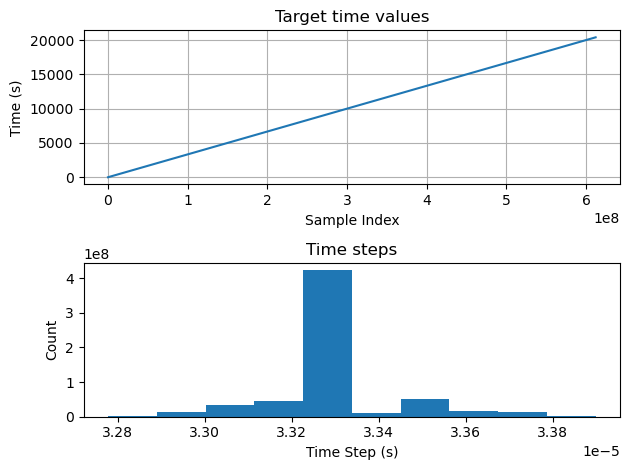

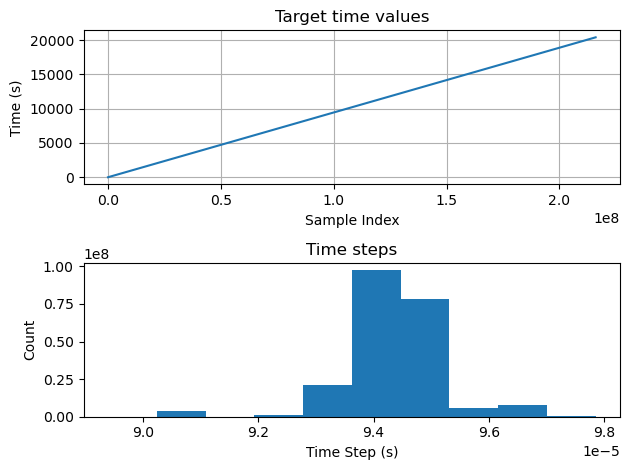

In [ ]:

preprocess_spikeglx(sess_dir, sync_nidq={'channel': [13]}, use_catgt_version=False)

## Antidromic processing
Analyzes antidromic stimulation responses. Uses `stim_chan` to detect stimulation times from the NIDQ file. Groups stimulation events and generates evoked field summary plots for each probe. Exclude problematic stimulation groups by adding their indices to `bad_groups`. Manually add stimulation parameters (region, current) in the `stim_notes` list below.

In [4]:
# locate ap, lfp, and nidq files
sess_files = get_session_dict(sess_dir)

# stim chan
stim_chan = 4

# get grouped stim times
stim_df = get_antistim_times(sess_files['nidq']['dclut'], stim_chan)

stim_df

,stim_times,start_time,end_time,num_pulses,duration,mean_interval
stim_group,,,,,,
0,"[18754.030773076924, 18754.035562962963, 18754...",18754.030773,18754.448360,3,0.417587,0.208794
1,"[18829.79219371069, 18831.78907567568, 18833.7...",18829.792194,18837.789067,5,7.996873,1.999218
2,"[19009.953739534885, 19011.953657142858, 19013...",19009.953740,19127.952811,60,117.999071,1.999984
3,"[19159.83593018868, 19161.8359375, 19163.83583...",19159.835930,19237.835359,40,77.999429,1.999985
4,"[19290.703760215056, 19292.703810691826, 19294...",19290.703760,19378.703138,45,87.999378,1.999986
5,"[19410.236145833333, 19412.23606046512, 19414....",19410.236146,19524.235405,58,113.999259,1.999987
6,"[19549.975424324322, 19551.975404166667, 19553...",19549.975424,19729.974354,91,179.998930,1.999988
7,"[19755.532713513516, 19757.532656603777, 19759...",19755.532714,19863.532004,55,107.999290,1.999987
8,"[19919.752702083333, 19921.75271904762, 19923....",19919.752702,20045.751933,64,125.999231,1.999988


In [5]:
# bad groups
bad_groups = [0,1]
stim_df = stim_df.drop(bad_groups).reset_index(drop=True)
stim_df

,stim_times,start_time,end_time,num_pulses,duration,mean_interval
0,"[19009.953739534885, 19011.953657142858, 19013...",19009.953740,19127.952811,60,117.999071,1.999984
1,"[19159.83593018868, 19161.8359375, 19163.83583...",19159.835930,19237.835359,40,77.999429,1.999985
2,"[19290.703760215056, 19292.703810691826, 19294...",19290.703760,19378.703138,45,87.999378,1.999986
3,"[19410.236145833333, 19412.23606046512, 19414....",19410.236146,19524.235405,58,113.999259,1.999987
4,"[19549.975424324322, 19551.975404166667, 19553...",19549.975424,19729.974354,91,179.998930,1.999988
5,"[19755.532713513516, 19757.532656603777, 19759...",19755.532714,19863.532004,55,107.999290,1.999987
6,"[19919.752702083333, 19921.75271904762, 19923....",19919.752702,20045.751933,64,125.999231,1.999988
7,"[20069.612212698416, 20071.612205660378, 20073...",20069.612213,20227.611406,80,157.999194,1.999990
8,"[20249.951842767296, 20251.951916981132, 20253...",20249.951843,20389.951066,71,139.999223,1.999989


Attach region and current information to each stimulation group before generating summaries.

In [6]:
# Add stimulation parameters from notes
stim_notes = [{'stim_group': 0, 'region': 'thalamus', 'current_uA': 500},
              {'stim_group': 1, 'region': 'thalamus', 'current_uA': 1000},
              {'stim_group': 2, 'region': 'pyramidal', 'current_uA': 500},
              {'stim_group': 3, 'region': 'pyramidal', 'current_uA': 500},
              {'stim_group': 4, 'region': 'pyramidal', 'current_uA': 1000},
              {'stim_group': 5, 'region': 'pyramidal', 'current_uA': 750},
              {'stim_group': 6, 'region': 'striatum', 'current_uA': 750},
              {'stim_group': 7, 'region': 'striatum', 'current_uA': 1000},
              {'stim_group': 8, 'region': 'striatum', 'current_uA': 500}]

stim_notes_df = pd.DataFrame(stim_notes).set_index('stim_group')
stim_df = stim_df.join(stim_notes_df)
stim_df = stim_df.dropna(subset=['region'])
stim_df

,stim_times,start_time,end_time,num_pulses,duration,mean_interval,region,current_uA
0,"[19009.953739534885, 19011.953657142858, 19013...",19009.953740,19127.952811,60,117.999071,1.999984,thalamus,500
1,"[19159.83593018868, 19161.8359375, 19163.83583...",19159.835930,19237.835359,40,77.999429,1.999985,thalamus,1000
2,"[19290.703760215056, 19292.703810691826, 19294...",19290.703760,19378.703138,45,87.999378,1.999986,pyramidal,500
3,"[19410.236145833333, 19412.23606046512, 19414....",19410.236146,19524.235405,58,113.999259,1.999987,pyramidal,500
4,"[19549.975424324322, 19551.975404166667, 19553...",19549.975424,19729.974354,91,179.998930,1.999988,pyramidal,1000
5,"[19755.532713513516, 19757.532656603777, 19759...",19755.532714,19863.532004,55,107.999290,1.999987,pyramidal,750
6,"[19919.752702083333, 19921.75271904762, 19923....",19919.752702,20045.751933,64,125.999231,1.999988,striatum,750
7,"[20069.612212698416, 20071.612205660378, 20073...",20069.612213,20227.611406,80,157.999194,1.999990,striatum,1000
8,"[20249.951842767296, 20251.951916981132, 20253...",20249.951843,20389.951066,71,139.999223,1.999989,striatum,500


Iterate over probes and stimulation groups to create QC PDFs of evoked field summaries, saving them under each probe's `qc_reports` directory.

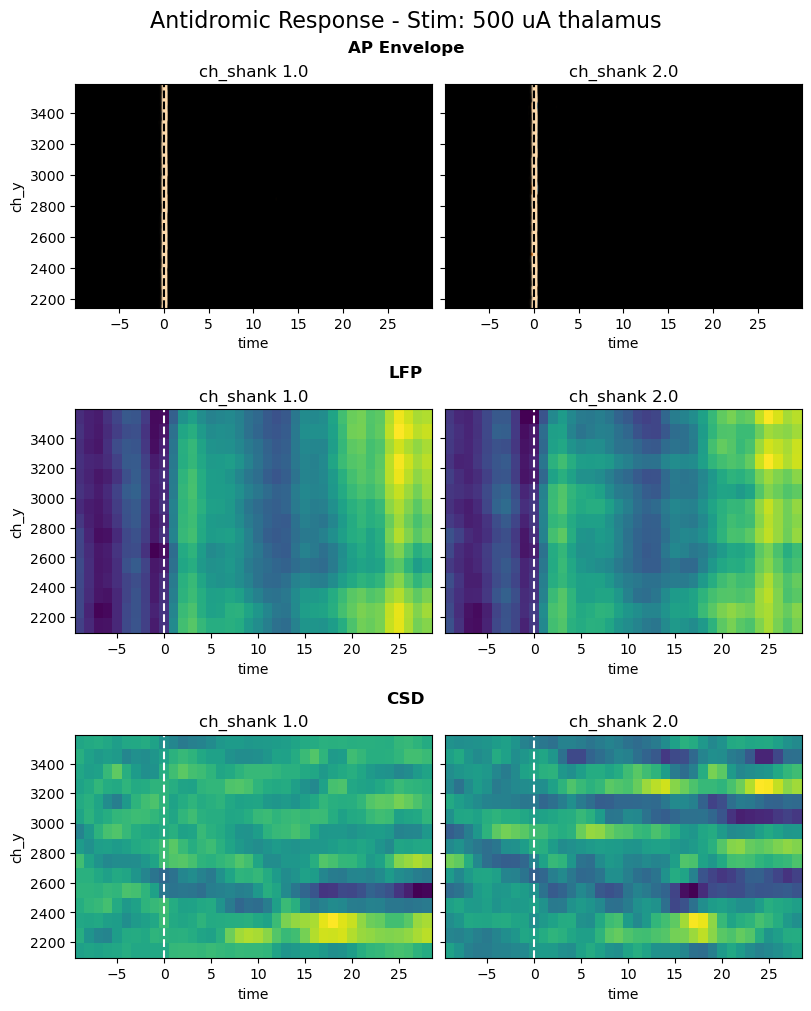

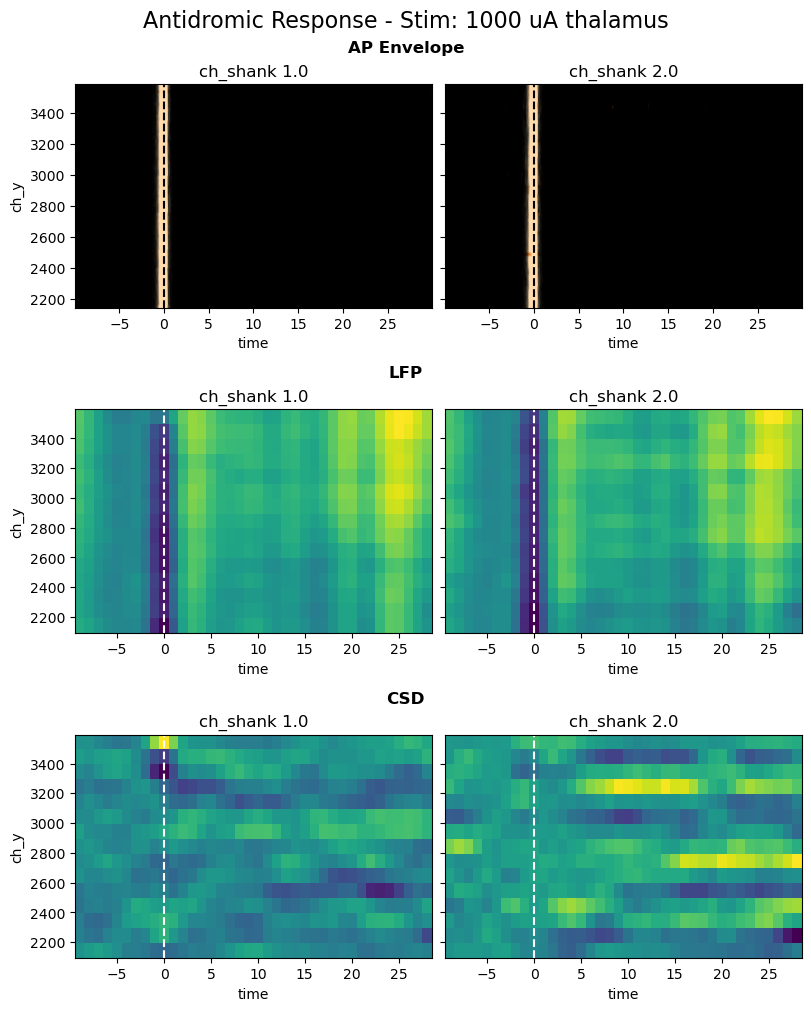

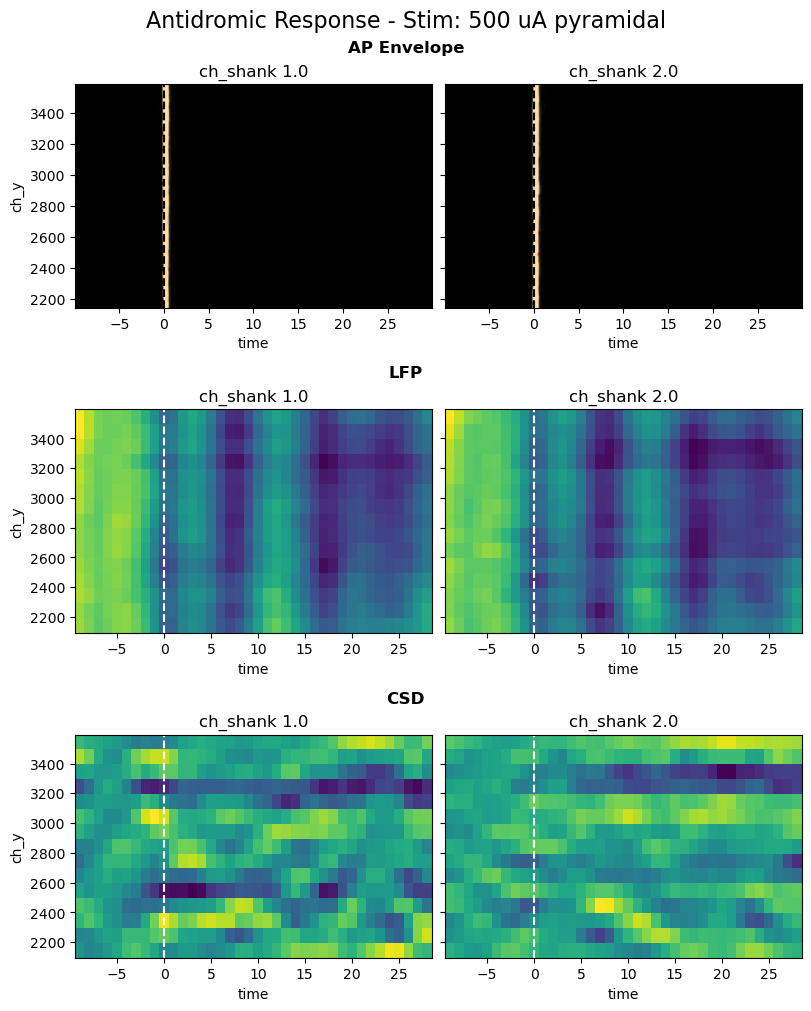

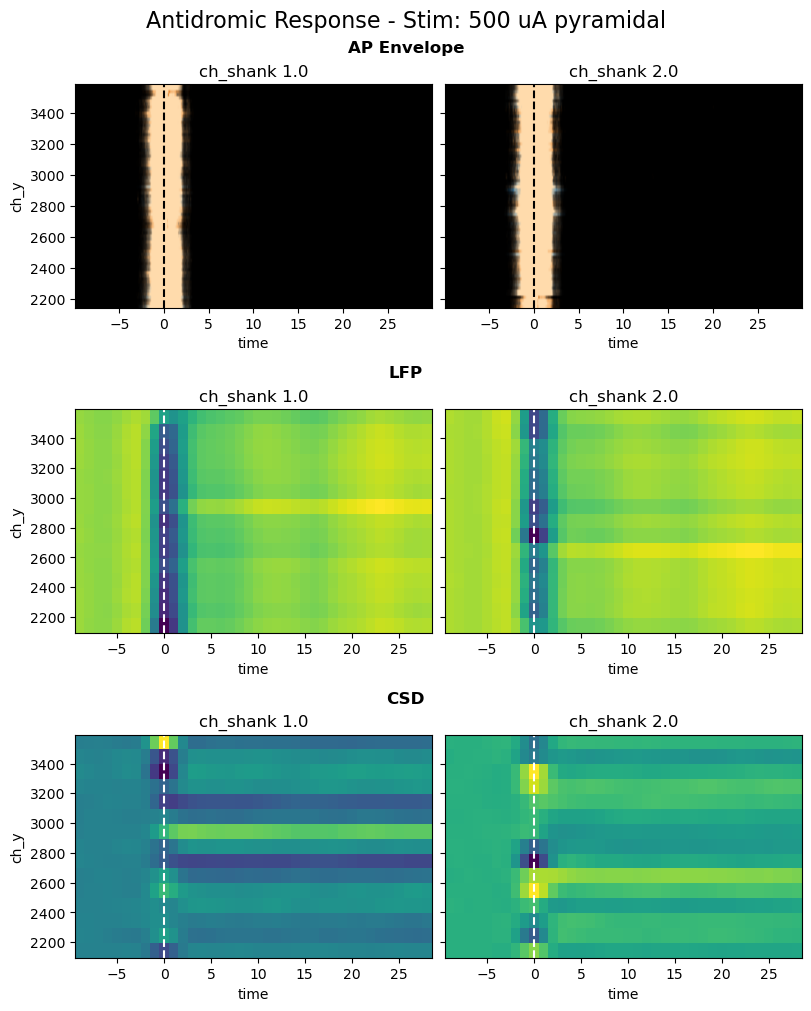

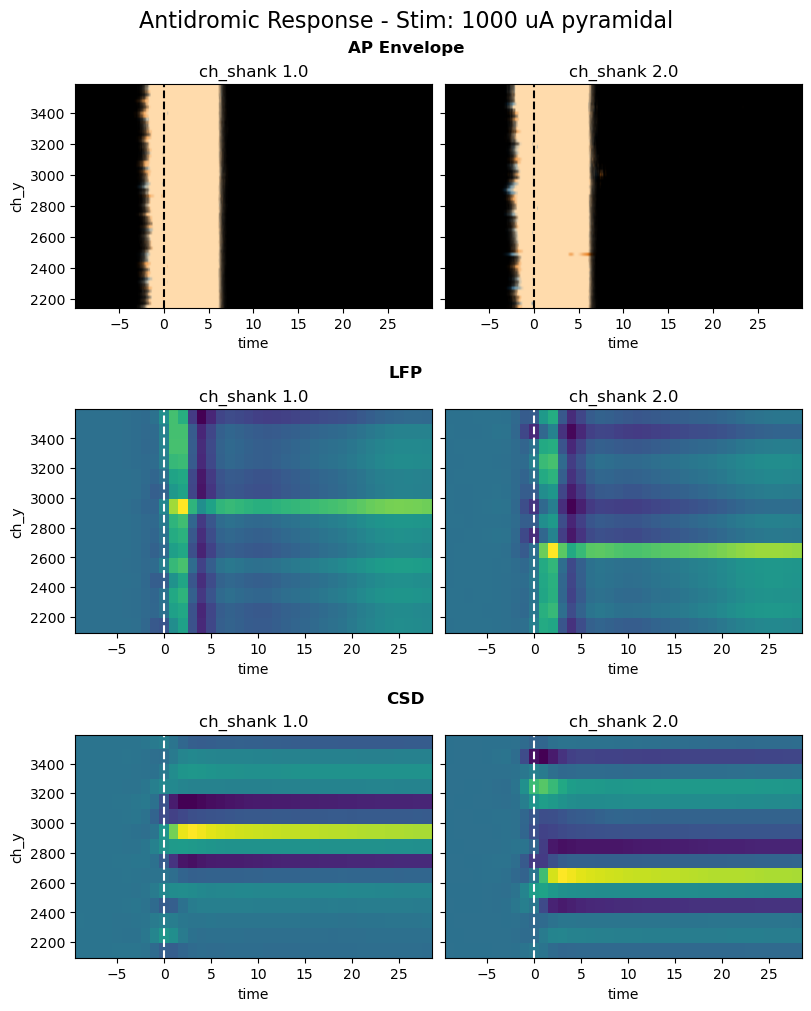

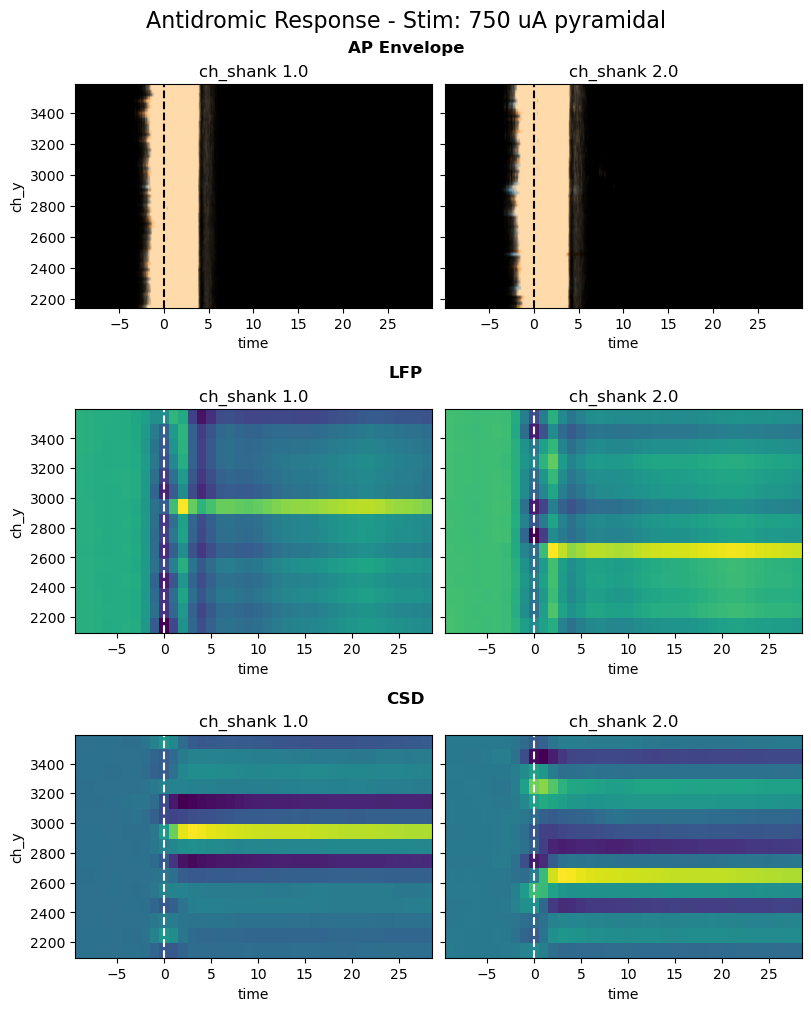

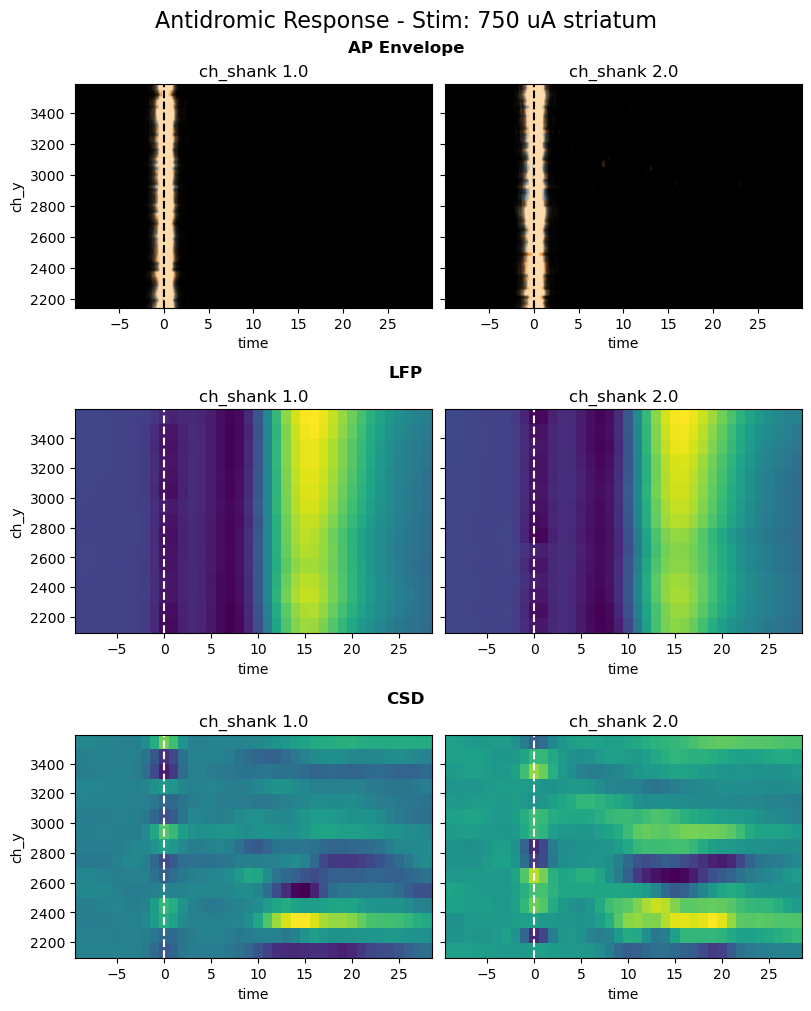

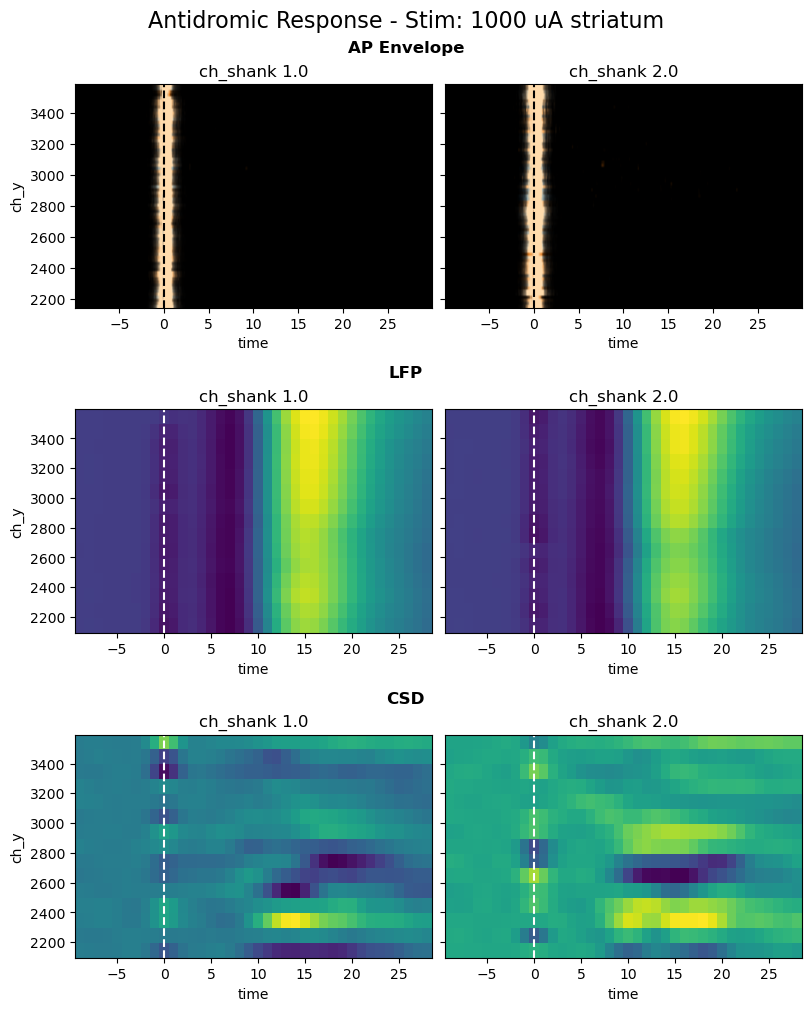

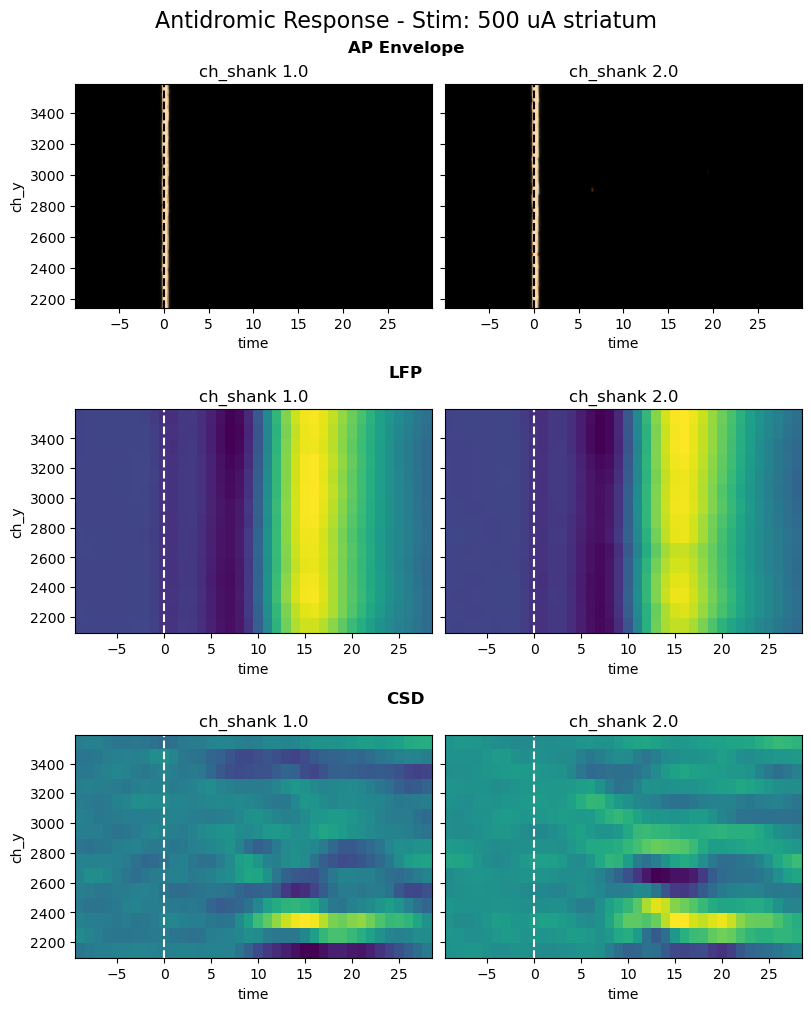

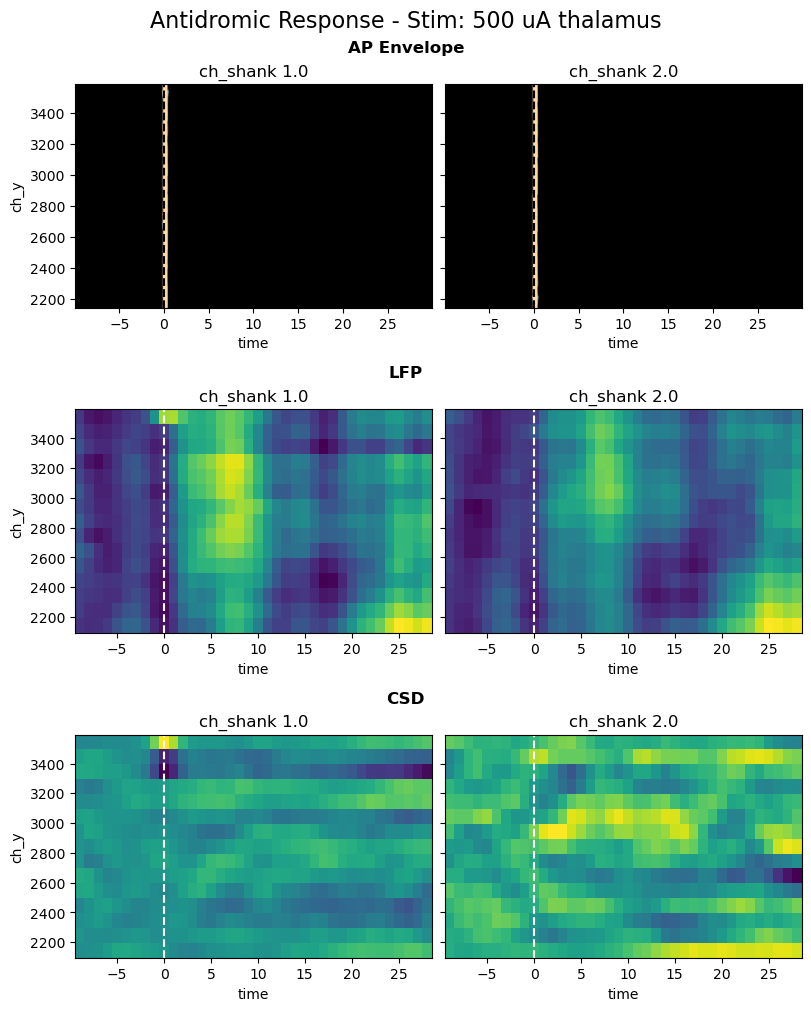

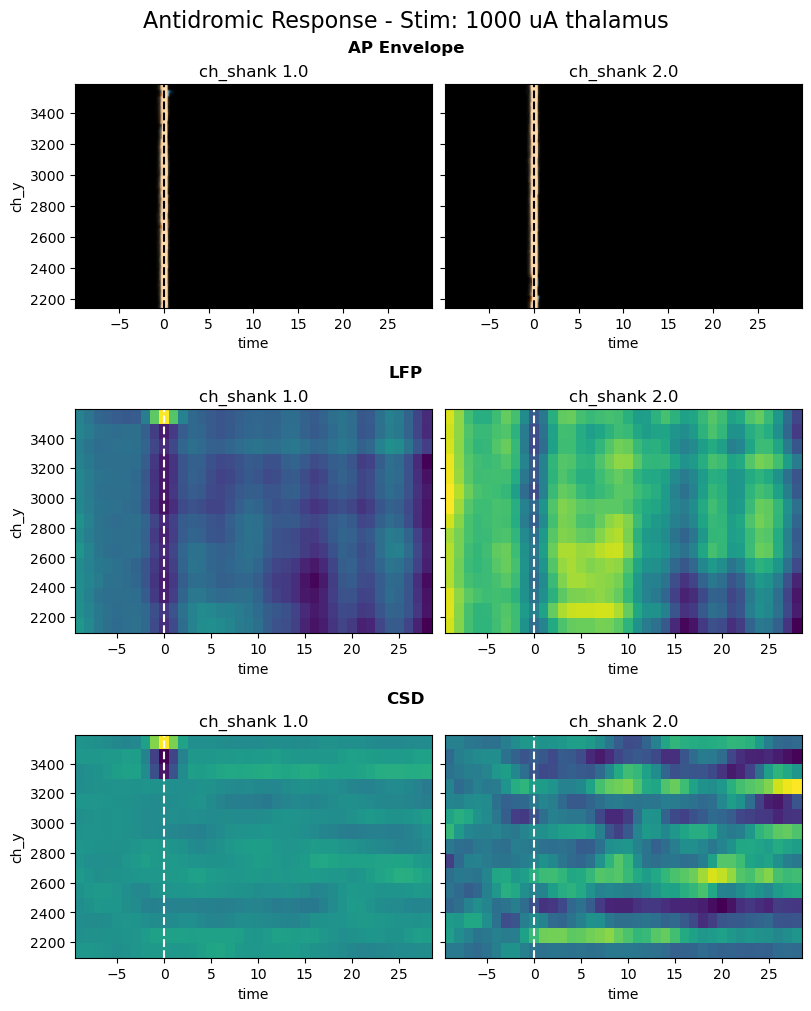

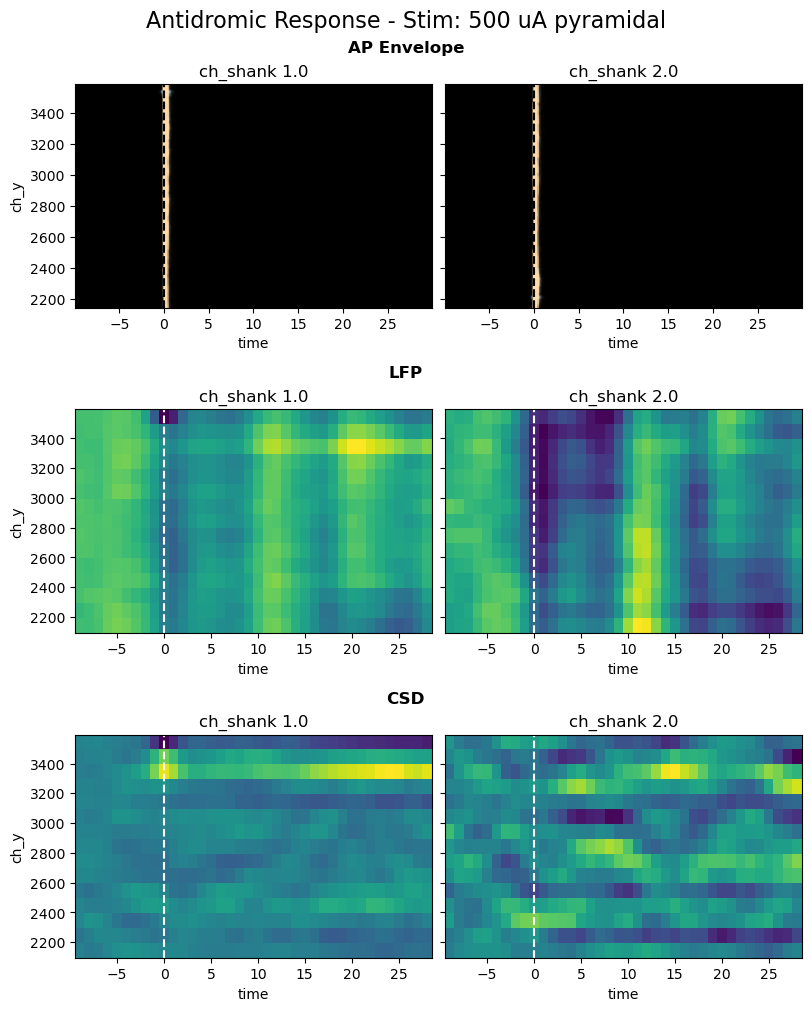

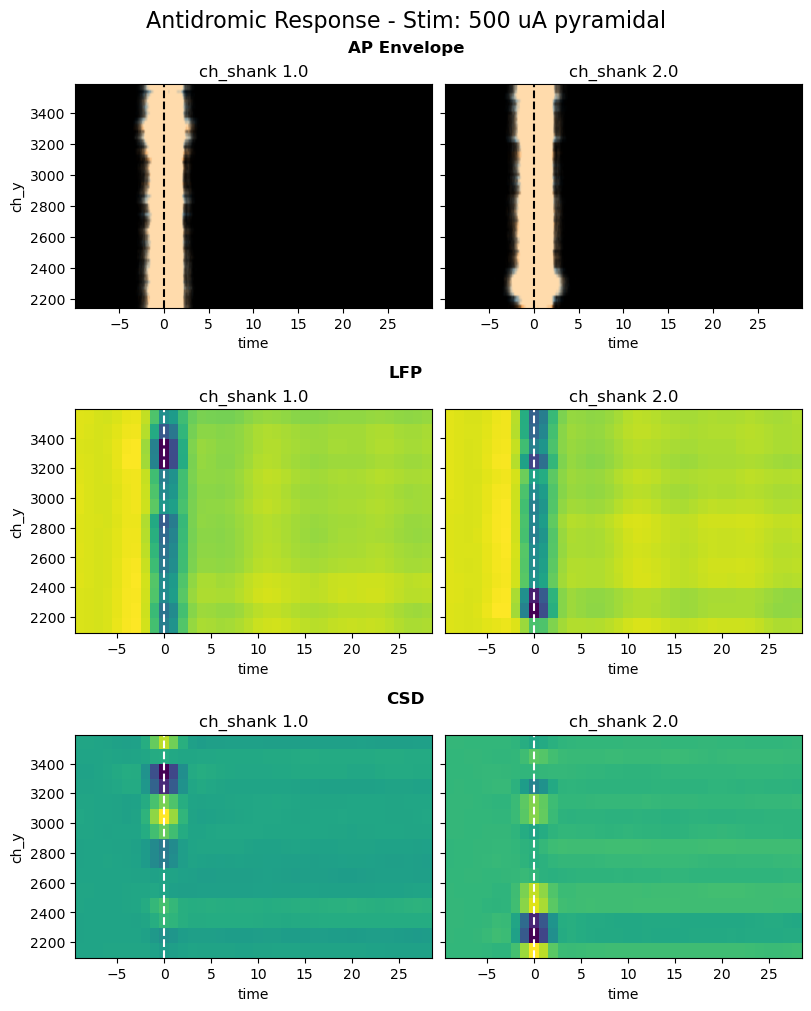

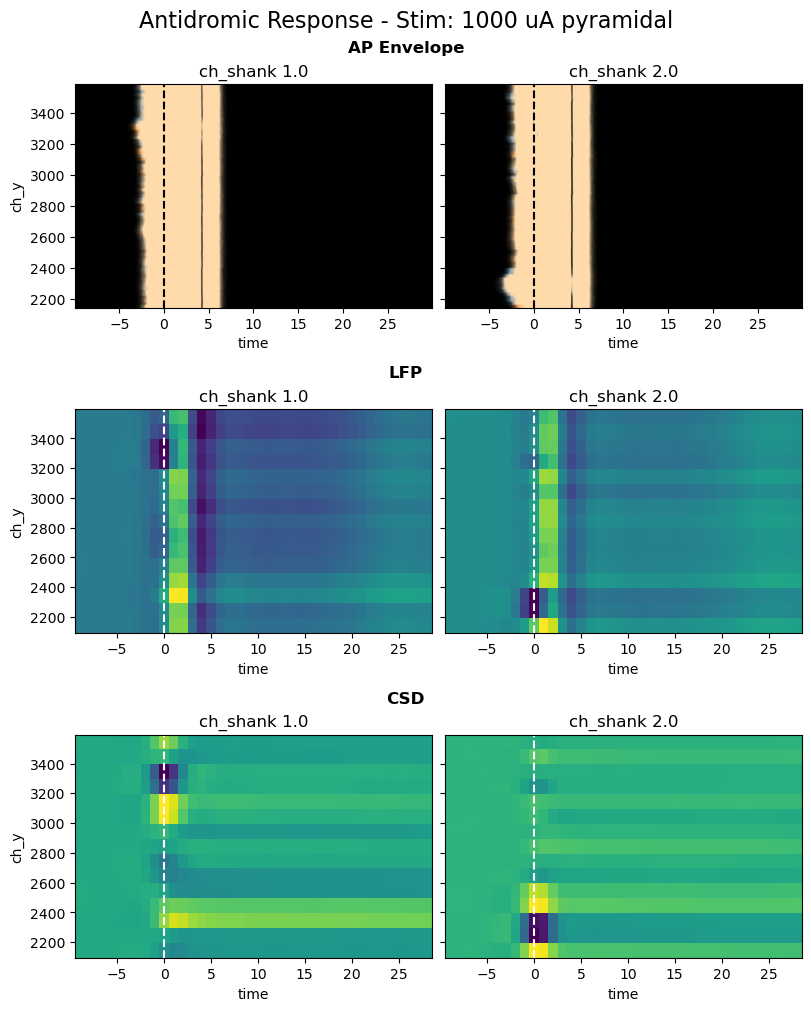

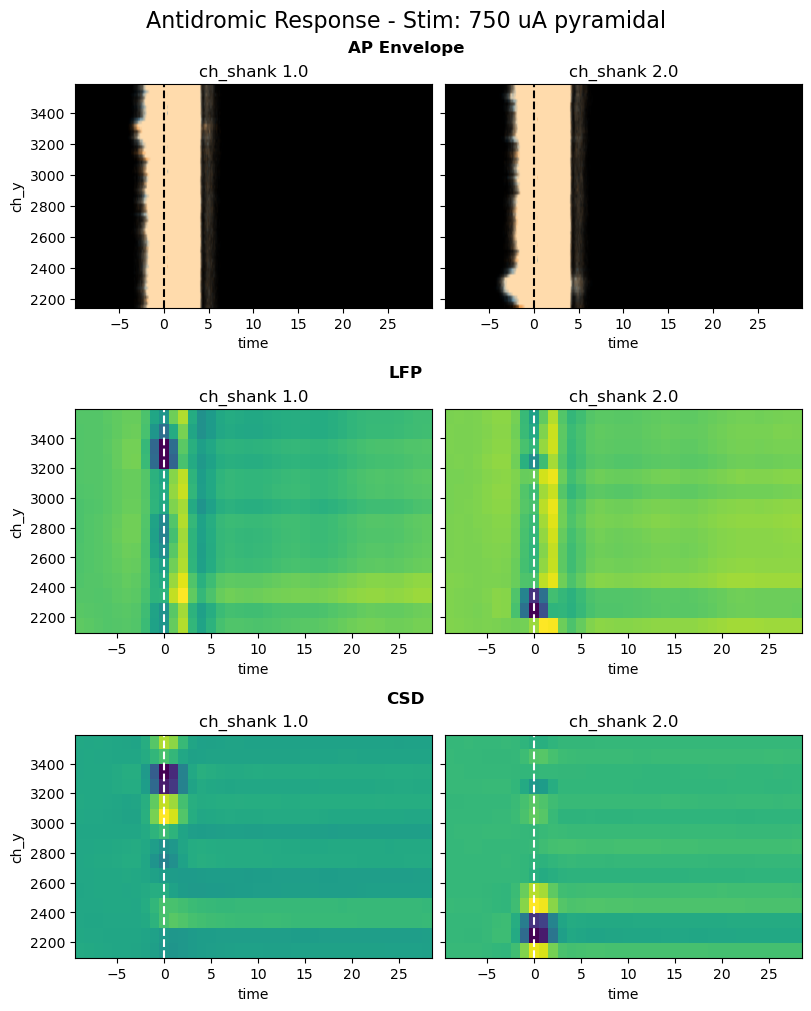

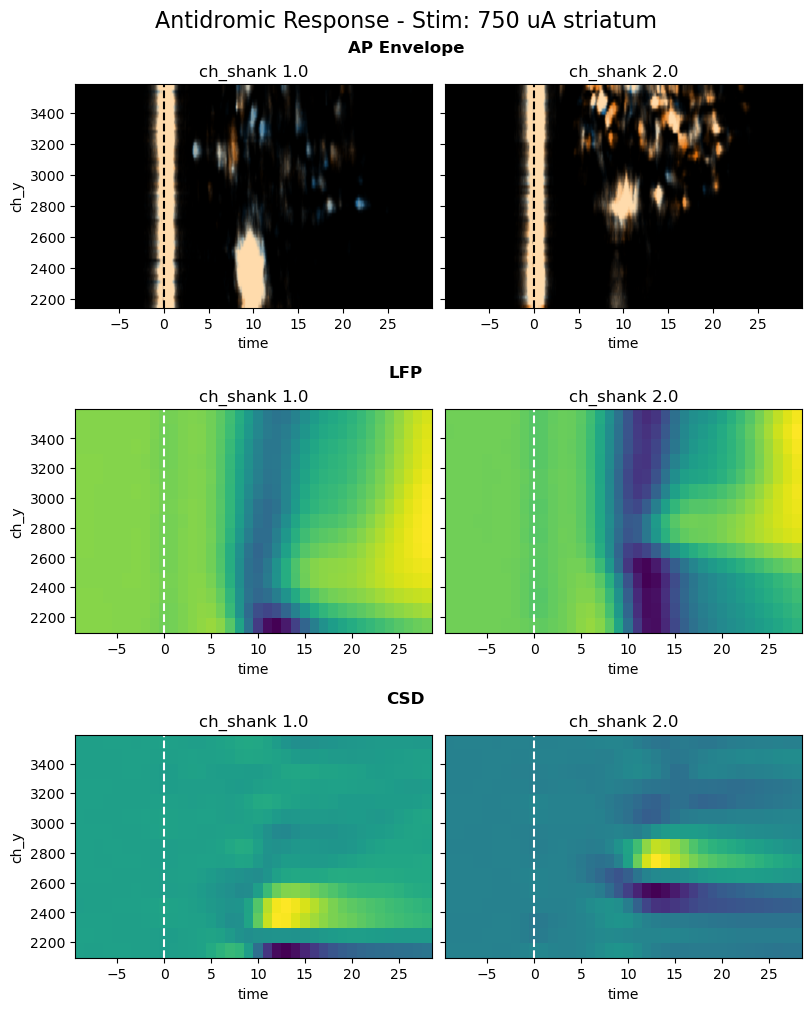

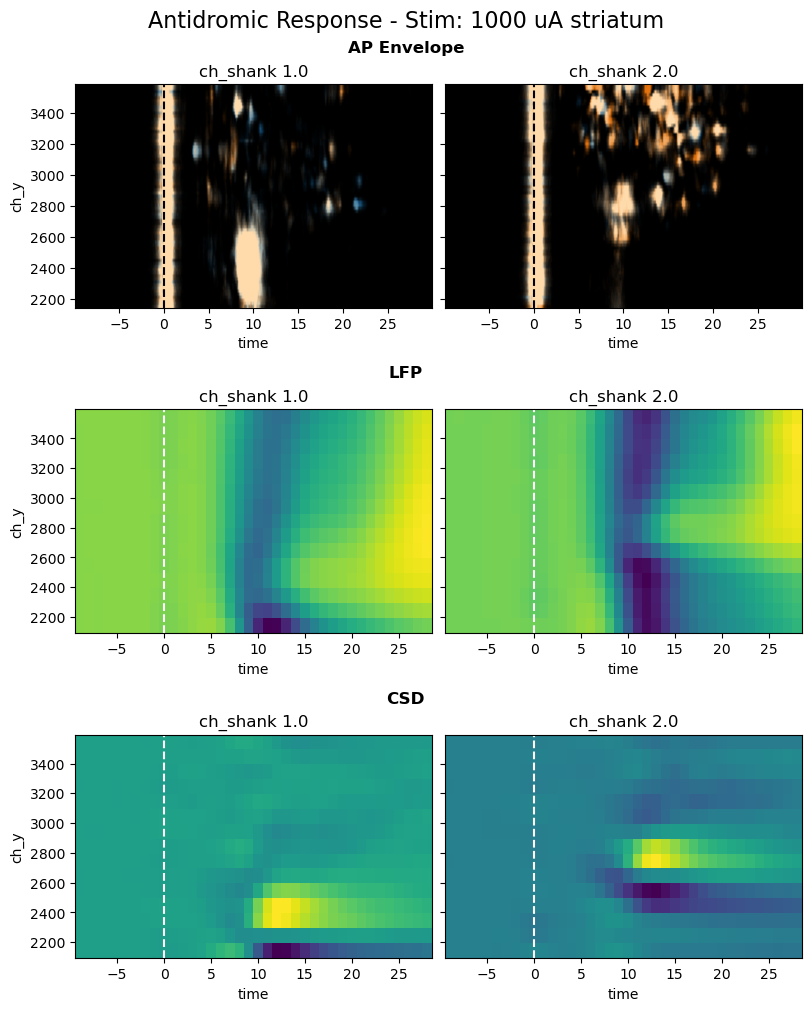

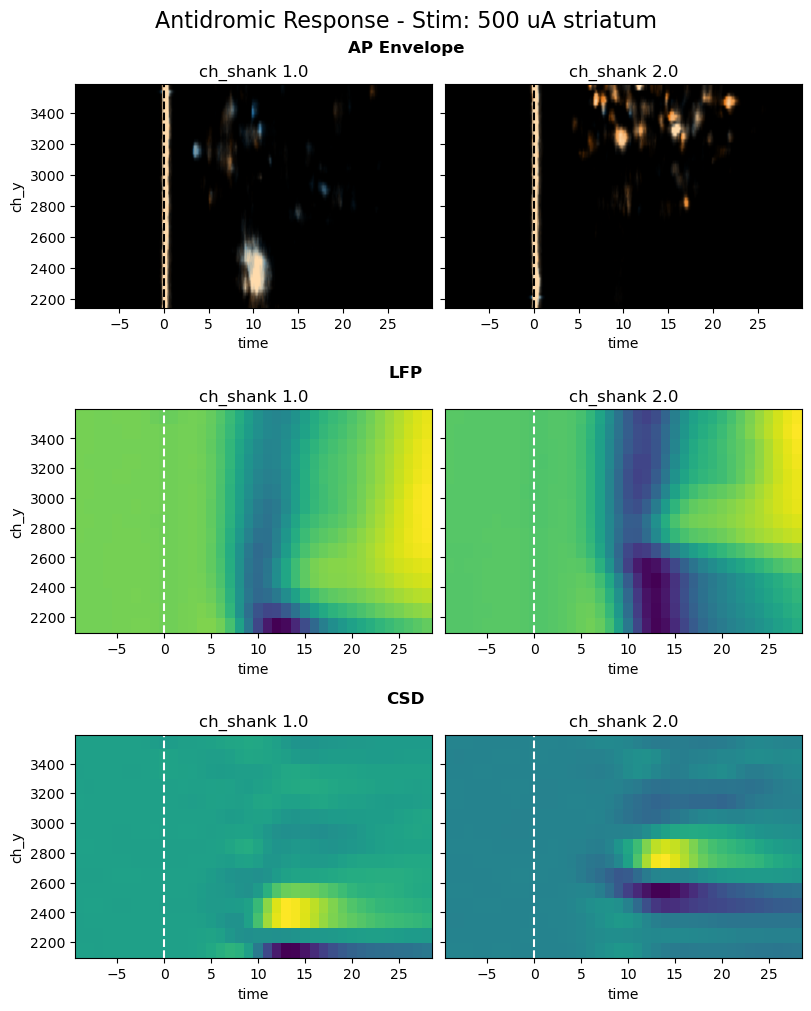

In [13]:
for probe in sess_files['imec']:
    qc_dir = os.path.join(probe['dir'], 'qc_reports')
    os.makedirs(qc_dir, exist_ok=True)
    for idx, row in stim_df.iterrows():
        summary = evoked_field_summary(row['stim_times'], probe['ap_dclut'], probe['lfp_dclut'])
        current_uA = row['current_uA']
        region = row['region']
        fig = plot_antidromic_summary(summary, current_uA, region)
        fig.savefig(os.path.join(qc_dir, f'antidromic_summary_stimgroup{idx}.pdf'))

Finally, save the antidromic stimulation times.

In [7]:
stim_df.to_json(os.path.join(sess_dir, 'antidromic.json'))

### Create and align reaching video

In [ ]:
# locate ap, lfp, and nidq files
sess_files = get_session_dict(sess_dir)

# directory where your images from the experiment are located
img_dir = "D:\\SortingTemp\\25-01-22_ZS02_Reach"

# Path to dclut file with the time code for your neural data. It is best to use the dclut file that was
# used as the reference for all other recording files
dcl_path = sess_files['imec'][0]['ap_dclut']

sync_channel = {'channel': [384]}

Combine image frames from `img_dir` into an MP4 and produce a barcode timing table for alignment.

In [ ]:
# convert the .tif files to a single .mp4 video file
vid_path, tbl_path = tif_to_video(img_dir)

100%|██████████| 62449/62449 [40:41<00:00, 25.58it/s]


Interactively select 8 barcode LED regions (start from the 2nd LED on the left) to decode video sync codes.

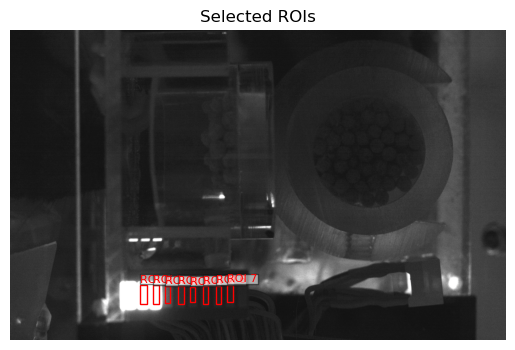

In [5]:
# Get ROIs for barcodes (start from the 2nd LED on the left, just draw 8 rectangles)
rois = create_video_rois(vid_path)

if len(rois) != 8:
    print('Incorrect number of ROIs')

Use barcode timestamps to align video frames to neural data (AP dclut) and write an aligned video/table.

Aligning barcodes: 100%|█████████▉| 62392/62449 [27:51<00:01, 37.32frames/s] 


'D:\\SortingTemp\\25-01-22_ZS02_Reach\\25-01-22_ZS02_Reach.csv'

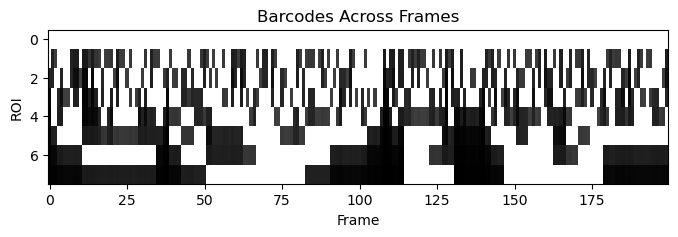

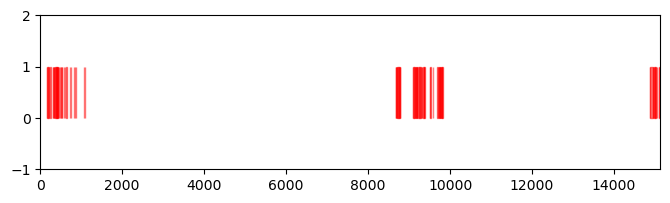

In [7]:
process_and_align_video(vid_path, tbl_path, rois, dcl_path, sync_channel)

### Behavioral state
Scores behavioral states (e.g., active, quiet, sleep) from LFP band power. Uses the probe specified by `probe_ind` and the LFP channel specified by `state_channel`. First, visualize LFP waveforms to select an appropriate channel, then run the state scoring algorithm.

Load the selected probe's LFP, extract a small time window, and demean it for visualization.

In [3]:
# locate ap, lfp, and nidq files
sess_files = get_session_dict(sess_dir)
probe_ind = 0
lfp_sig = load_lfp_full_xr(sess_files['imec'][probe_ind]['lfp_dclut'])

lfp_snip = lfp_sig.sel(time=slice(10.0, 10.5))
lfp_snip = lfp_snip - lfp_snip.median(dim='time')


Visualize a small LFP snippet across channels to pick `channel` for behavioral state analysis.

<Axes: >

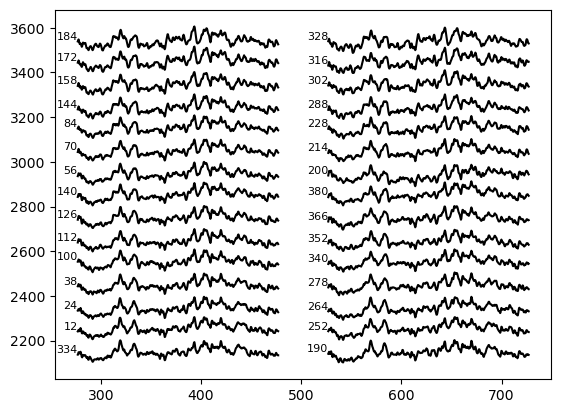

In [4]:
# Plot lfp snippets on grid to choose channel for state scoring
wave_map_xr(lfp_snip, label_coord='channel', x_scale=0.4)

Run `states_lfp_only` on the chosen channel, plot band power with state labels, and save the state array to disk.

c:\users\dbh60\documents\mimo\mimo_pack\mimo_pack\math\curvefitting.py:203: RuntimeWarning: invalid value encountered in log10
  return offset - np.log10(knee + x**exp)


Error fitting spectrum: Optimal parameters not found: Number of calls to function has reached maxfev = 800.


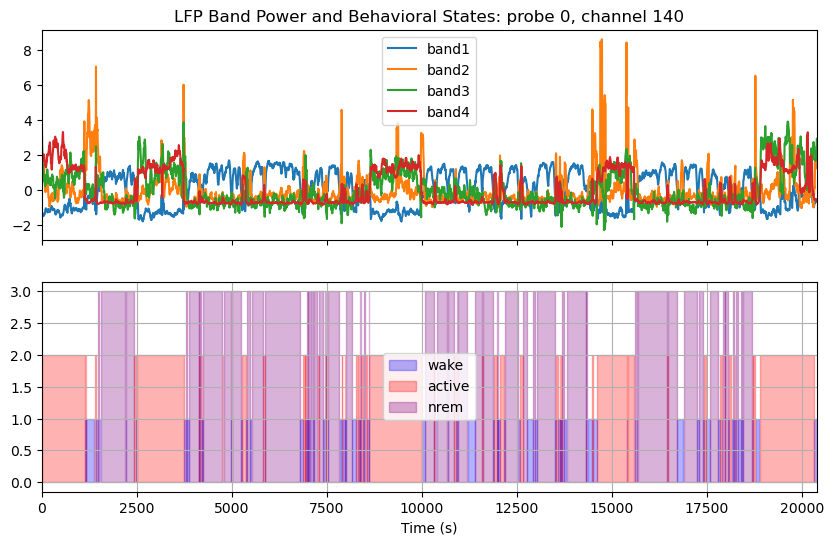

In [12]:
channel = 140
states, spec_z = states_lfp_only(lfp_sig.sel(channel=channel))

os.makedirs('qc_reports', exist_ok=True)

fig, axs = plt.subplots(2,1,figsize=(10, 6), sharex=True)
plot_band_power_states(spec_z, states, axs=axs)
axs[0].set_title('LFP Band Power and Behavioral States: probe {}, channel {}'.format(probe_ind, channel))
axs[1].set_xlabel('Time (s)')
fig.savefig('qc_reports/behavioral_states_lfp.pdf')

# save states xarray
states.to_netcdf(os.path.join(sess_dir, 'states.nc'))